# Epic of Sun - Desafio 1
Training  the model.
***

This jupyter notebook trains a UNet for sugarcane identification from satellite images.

It is divided in 6 parts:
* Loading libraries and data
* Separating the dataset in train, validate, and test sets
* Build the model
* Train the model
* Evaluate the model

***

## Loading libraries and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

import geopandas as gpd
import rasterio
from rasterio.features import rasterize

import json
import joblib
from pathlib import Path
import os

import tensorflow as tf
from sklearn.model_selection import train_test_split
#import segmentation_models as sm
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.models import load_model

import keras_tuner as kt

from sklearn.metrics import (
	classification_report, 
	confusion_matrix, 
	roc_auc_score,
	roc_curve,
	precision_recall_curve, 
    precision_score,
    recall_score,
    f1_score,
	recall_score)

2026-07-25 23:27:15.869168: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1785032835.985045  867294 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785032836.020657  867294 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-25 23:27:16.199687: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
# Flags
flag_hyperparameter_tuning = False
flag_load_model = True

In [3]:
# Get the directory where THIS script is located
base_path = Path.cwd()

In [4]:
# Specify the paths to the mesh and image files
patches_path = base_path / "data" / "processed"

In [5]:
patch_index = pd.read_csv(patches_path / "patch_index.csv" )

print(patch_index.head())
print(len(patch_index))

     scene  patch_id  row_start  col_start  \
0  scene02         0          0          0   
1  scene02         1          0         64   
2  scene02         2          0        128   
3  scene02         3          0        192   
4  scene02         4          0        256   

                                   x_patch_path  \
0  data/processed/scene02/images/patch_0000.npy   
1  data/processed/scene02/images/patch_0001.npy   
2  data/processed/scene02/images/patch_0002.npy   
3  data/processed/scene02/images/patch_0003.npy   
4  data/processed/scene02/images/patch_0004.npy   

                                  y_patch_path  sugarcane_pixels  
0  data/processed/scene02/masks/patch_0000.npy                 0  
1  data/processed/scene02/masks/patch_0001.npy                 0  
2  data/processed/scene02/masks/patch_0002.npy                 0  
3  data/processed/scene02/masks/patch_0003.npy                 0  
4  data/processed/scene02/masks/patch_0004.npy                 0  
2622


## Separating the dataset in train, validate, and test sets

In [6]:
# Random split for one Sentinel scene
# With more scenes, split by scene, not by patch.

# Split the dataset into training and test sets
train_df, test_df = train_test_split(
    patch_index,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# Split the training set into training and validation sets
train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42
)

In [7]:
# Function to add spectral indices to the input patches

def add_spectral_indices(X_data, eps=1e-8):
    """
    Appends spectral indices (NDVI, NDWI, EVI) as extra channels to input patches.
    
    Expected input shape: (..., H, W, 4) or (H, W, 4)
    Channels: [Blue (0), Green (1), Red (2), NIR (3)]
    """
    # Extract individual bands along the last axis
    blue  = X_data[..., 0]
    green = X_data[..., 1]
    red   = X_data[..., 2]
    nir   = X_data[..., 3]

    # 1. NDVI: (NIR - Red) / (NIR + Red)
    ndvi = (nir - red) / (nir + red + eps)

    # 2. NDWI: (Green - NIR) / (Green + NIR)
    ndwi = (green - nir) / (green + nir + eps)

    # 3. EVI: 2.5 * (NIR - Red) / (NIR + 6*Red - 7.5*Blue + 1)
    evi = 2.5 * (nir - red) / (nir + 6.0 * red - 7.5 * blue + 1.0 + eps)

    # Re-add channel dimension to calculated 2D indices
    ndvi = np.expand_dims(ndvi, axis=-1)
    ndwi = np.expand_dims(ndwi, axis=-1)
    evi  = np.expand_dims(evi, axis=-1)

    # Stack original bands with new index channels along the channel axis
    X_expanded = np.concatenate([X_data, ndvi, ndwi, evi], axis=-1)

    return X_expanded

In [8]:
# Function to load the patches individually

def load_dataset(df, base_path, compute_indices=True):
    """
    Loads .npy patches listed in a DataFrame into memory as NumPy arrays.
    
    Parameters:
        df (pd.DataFrame): Dataframe slice (train, val, or test) containing patch paths.
        base_path (Path): Root project directory to resolve relative file paths.
    """
    X = []
    Y = []

    for _, row in df.iterrows():
        # Resolve path relative to base_path (or remove base_path / if paths in CSV are absolute)
        x_path = base_path / row["x_patch_path"]
        y_path = base_path / row["y_patch_path"]

        x = np.load(x_path).astype(np.float32)
        y = np.load(y_path).astype(np.float32)

        X.append(x)
        Y.append(y)

    # Stack into 4D arrays: (N, H, W, C)
    X = np.array(X, dtype=np.float32)
    Y = np.array(Y, dtype=np.float32)

	# Append spectral indices if requested
    if compute_indices:
        X = add_spectral_indices(X)

    return X, Y

In [9]:
# Load the datasets

# Pass base_path so Path resolution works smoothly across notebooks
X_train, y_train = load_dataset(train_df, base_path, compute_indices=True)
X_val, y_val = load_dataset(val_df, base_path, compute_indices=True)
X_test, y_test = load_dataset(test_df, base_path, compute_indices=True)

In [10]:
# Print the shapes and data types of the datasets
# Shape will now be (N, 128, 128, 7) -> [Blue, Green, Red, NIR, NDVI, NDWI, EVI]
print("Training set:")
print(X_train.shape)
print(y_train.shape)

print(X_train.dtype)
print(y_train.dtype)

print("\nValidation set:")
print(X_val.shape)
print(y_val.shape)

print(X_val.dtype)
print(y_val.dtype)

print("\nTest set:")
print(X_test.shape)
print(y_test.shape)

print(X_test.dtype)
print(y_test.dtype)

print(np.unique(y_train))

Training set:
(1677, 128, 128, 7)
(1677, 128, 128, 1)
float32
float32

Validation set:
(420, 128, 128, 7)
(420, 128, 128, 1)
float32
float32

Test set:
(525, 128, 128, 7)
(525, 128, 128, 1)
float32
float32
[0. 1.]


In [11]:
# Print the first row of the patch index
print(patch_index.iloc[0])

scene                                                    scene02
patch_id                                                       0
row_start                                                      0
col_start                                                      0
x_patch_path        data/processed/scene02/images/patch_0000.npy
y_patch_path         data/processed/scene02/masks/patch_0000.npy
sugarcane_pixels                                               0
Name: 0, dtype: object


## Build the Model

In [12]:
# Convolution block
# Each block performs Conv -> ReLU -> Conv -> ReLU

def conv_block(inputs, filters):

    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        activation="relu"
    )(inputs)

    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        activation="relu"
    )(x)

    return x

In [13]:
# Encoder block
# Each block performs:
#  extracts features
#  saves them for the skip connection
#  downsamples by 2

def encoder_block(inputs, filters):
    x = conv_block(inputs, filters)
    p = layers.MaxPooling2D((2,2))(x)
    return x, p

In [14]:
# Decoder block
# Each block performs:
#  upsamples
#  concatenates the skip connection
#  performs two convolutions

def decoder_block(inputs, skip, filters):

    x = layers.Conv2DTranspose(
        filters,
        2,
        strides=2,
        padding="same"
    )(inputs)
	
    x = layers.Concatenate()([x, skip])

    x = conv_block(x, filters)

    return x

In [15]:
# Function to build the network, compile it, use tunned hyperparameters, and return the model

def build_unet(input_shape=(128,128,7), init_filters=32, lr=1e-3):
    inputs = layers.Input(input_shape)
    
    # Encoder
    s1, p1 = encoder_block(inputs, init_filters)  # 32
    s2, p2 = encoder_block(p1, init_filters * 2)  # 64
    s3, p3 = encoder_block(p2, init_filters * 4)  # 128
    s4, p4 = encoder_block(p3, init_filters * 8)  # 256
    
    # Bottleneck
    b1 = conv_block(p4, init_filters * 16)        # 512
    
    # Decoder
    d1 = decoder_block(b1, s4, init_filters * 8)  # 256
    d2 = decoder_block(d1, s3, init_filters * 4)  # 128
    d3 = decoder_block(d2, s2, init_filters * 2)  # 64
    d4 = decoder_block(d3, s1, init_filters)      # 32
    
    # Output
    outputs = layers.Conv2D(1, 1, activation="sigmoid")(d4)
    model = Model(inputs, outputs)
    
    # Unified comilation with the original metrics
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(),
            tf.keras.metrics.Precision(),
            tf.keras.metrics.Recall()
        ]
    )
    return model

In [16]:
# Wrapper function for Keras Tuner to tune hyperparameters

def tune_wrapper(hp):
    # Define the hyperparameters to tune
	# 1. Structural hyperparameters
    hp_filters = hp.Choice("init_filters", values=[8, 16, 32, 64])
    hp_lr = hp.Float("lr", min_value=1e-5, max_value=1e-2, sampling="log")
    
	# 2. Training hyperparameter (Focused on hardware economy)
    hp.Choice("batch_size", values=[16, 32, 64, 128]) 

    # Call original build_unet function with the hyperparameters
    return build_unet(init_filters=hp_filters, lr=hp_lr)

In [17]:
# Hyperparameter search

# Custom Tuner that successfully extracts and applies the batch size
class CustomRandomSearch(kt.RandomSearch):
    def run_trial(self, trial, *args, **kwargs):
        # Safely pull the active hyperparameter sample assigned by Keras Tuner
        hp = trial.hyperparameters
        
        # Inject it into kwargs so tf.keras.Model.fit receives it smoothly
        kwargs['batch_size'] = hp.get('batch_size') 
        return super(CustomRandomSearch, self).run_trial(trial, *args, **kwargs)

if flag_hyperparameter_tuning:
	# Configuration for low processing
	tuner = CustomRandomSearch(
		tune_wrapper,
		objective="val_loss",
		max_trials=30, # Number of different hyperparameter combinations to try
		executions_per_trial=1,
		directory="unet_tuner_results", # Directory to store the results of the hyperparameter search
		project_name="sugarcane_fast",
		overwrite=True # Cleans up older, failed configuration caches
	)

	# Stop early if the model is not improving to save time
	fast_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=2)

	# Execute the hyperparameter search
	tuner.search(
		X_train, y_train,
		validation_data=(X_val, y_val),
		epochs=10,
		callbacks=[fast_stop]
	)

	# Extract and print the best hyperparameters
	best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
	print(f"Best learning rate: {best_hps.get('lr')}")
	print(f"Best init_filters:  {best_hps.get('init_filters')}")
	print(f"Best batch_size:    {best_hps.get('batch_size')}")

	# Save data in JSON file
	best_params = {
		"lr": best_hps.get("lr"), 
		"init_filters": best_hps.get("init_filters"),
		"batch_size": int(best_hps.get("batch_size"))
		}

	json_path = base_path / "models" / "best_sugarcane_params.json"
	with open(json_path, "w") as f:
		json.dump(best_params, f)
	print(f"Best hyperparameters saved to {json_path}")

In [18]:
# Create the model with the best hyperparameters

# Load the best hyperparameters from the JSON file
json_path = base_path / "models" / "best_sugarcane_params.json"

with open(json_path, "r") as f:
    saved_params = json.load(f)

# Create the model with the best hyperparameters
model = build_unet(
    init_filters=saved_params["init_filters"], 
    lr=saved_params["lr"]
)

model.summary()

I0000 00:00:1785032848.603170  867294 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9709 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 7)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      2,048 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 256) │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8, 512) │  1,180,160 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 8, 8, 512) │  2,359,808 │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │    524,544 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 512)              │            │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 7,761,249 (29.61 MB)

 Trainable params: 7,761,249 (29.61 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# You can just load the model if already trained and not run the random search and best model again

if flag_load_model:
	model_path = base_path / "models" / "unet_sugarcane.keras"
	history_path = base_path / "models" / "training_history.json"

	if model_path.exists():
		try:
			# Pass str(model_path) to ensure compatibility
			model = load_model(str(model_path), compile=False)
			print("Successfully loaded saved model.")
		except Exception as e:
			print(f"File exists, but load_model failed with error:\n{e}")
	else:
		print("File does not exist at the specified path. Check your working directory or base_path.")
	
	if history_path.exists():
		try:
			with open(str(history_path), 'r') as f:
				history = json.load(f)
			print("Successfully loaded saved training history.")
		except Exception as e:
			print(f"File exists, but loading training history failed with error:\n{e}")
	else:
		print("Training history file does not exist at the specified path. Check your working directory or base_path.")
else:
	print("Model loading skipped. Training a new model from scratch or using hyperparameter tuning results.")

Model loading skipped. Training a new model from scratch or using hyperparameter tuning results.


## Train the model

In [20]:
# Checkpoint callback to save the best model based on validation loss
model_path = base_path / "models" / "unet_sugarcane.keras"

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    model_path,
    monitor="val_loss",
    save_best_only=True
)

In [21]:
# Checkpoint callback to save the best model based on validation loss
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [22]:
# Checkpoint callback to reduce learning rate when validation loss plateaus
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1
)

In [23]:
# Train the model
if not flag_load_model:
	print("Training a new model.")
	history = model.fit(
		X_train, y_train,
		validation_data=(X_val, y_val),
		epochs=50,
		batch_size=saved_params["batch_size"],
		callbacks=[checkpoint, early_stop, reduce_lr],
		verbose=1
	)
	history_dict = history.history
else:
	print("Model loaded, skipping training.")

Training model.


2026-07-25 23:27:30.425690: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 769327104 exceeds 10% of free system memory.
2026-07-25 23:27:31.300921: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 769327104 exceeds 10% of free system memory.


Epoch 1/50


I0000 00:00:1785032856.409382  868628 service.cc:148] XLA service 0x742e0810d170 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785032856.412977  868628 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-07-25 23:27:36.560650: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1785032857.242698  868628 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1785032883.309652  868628 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


27/27 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - binary_accuracy: 0.6690 - loss: 0.5252 - precision: 0.7689 - recall: 0.1395 - val_binary_accuracy: 0.8888 - val_loss: 0.3559 - val_precision: 0.8611 - val_recall: 0.8300 - learning_rate: 0.0016
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 198ms/step - binary_accuracy: 0.9065 - loss: 0.3263 - precision: 0.8700 - recall: 0.8762 - val_binary_accuracy: 0.9176 - val_loss: 0.2991 - val_precision: 0.8434 - val_recall: 0.9514 - learning_rate: 0.0016
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 209ms/step - binary_accuracy: 0.9201 - loss: 0.2309 - precision: 0.8463 - recall: 0.9557 - val_binary_accuracy: 0.9183 - val_loss: 0.2035 - val_precision: 0.8348 - val_recall: 0.9684 - learning_rate: 0.0016
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 205ms/step - binary_accuracy: 0.9300 - loss: 0.1822 - precision: 0.8703 - recall: 0.9510 - val_binary_accuracy: 0.9313 - val_loss: 0.1814 - val_precision: 0.8634 - val_recall: 0.9648 - learning_rate: 0.0016
Epoch 5/50
27/27 ━━━━

In [24]:
# Save the model and its history for future use.
# The model is saved in the Keras format (.keras) which includes both architecture and weights.

if not flag_load_model:
	# Save the model.
	model_path = base_path / "models" / "unet_sugarcane.keras"
	model.save(str(model_path))
	print(f"Model saved to '{model_path}'")

	# Save the training history as a JSON file for future reference.
	history_path = base_path / "models" / "training_history.json"
	with open(str(history_path), 'w') as f:
		json.dump(history_dict, f)
	print(f"Training history saved to '{history_path}'")
else:
	print("Model loaded, skipping saving model and history.")

Model saved to '/home/fdesmello/Git/spacesugar/models/unet_sugarcane.keras'
Training history saved to '/home/fdesmello/Git/spacesugar/models/training_history.json'


## Evaluate the model


Visualization saved as '/home/fdesmello/Git/spacesugar/figures/loss_accuracy.png'


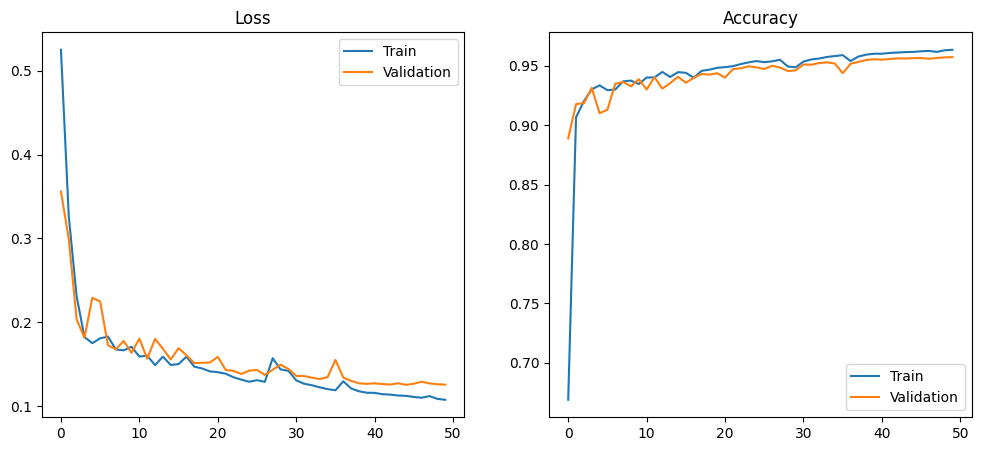

In [25]:
# Plot the learning curves
if history_dict:
	plt.figure(figsize=(12,5))

	plt.subplot(1,2,1)
	plt.plot(history.history["loss"], label="Train")
	plt.plot(history.history["val_loss"], label="Validation")
	plt.title("Loss")
	plt.legend()

	plt.subplot(1,2,2)
	plt.plot(history.history["binary_accuracy"], label="Train")
	plt.plot(history.history["val_binary_accuracy"], label="Validation")
	plt.title("Accuracy")
	plt.legend()

	file_path = base_path / "figures" / "loss_accuracy.png"
	plt.savefig(file_path, dpi=300, bbox_inches='tight')
	print(f"\nVisualization saved as '{file_path}'")

	plt.show()
else:
	print("Model loaded, skipping training and learning curve visualization.")

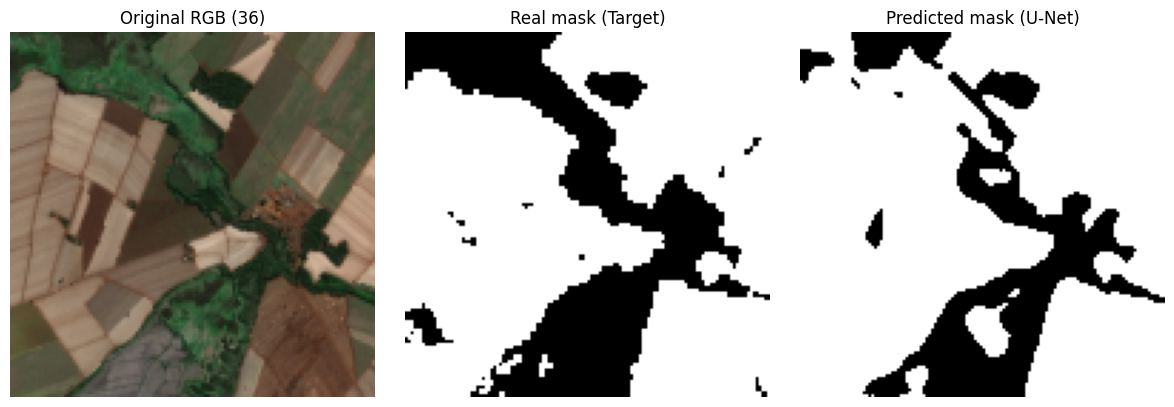

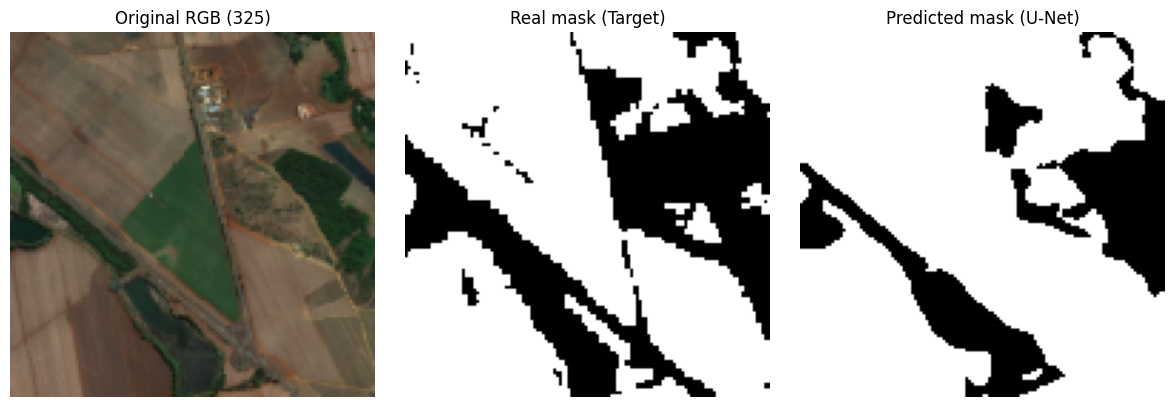

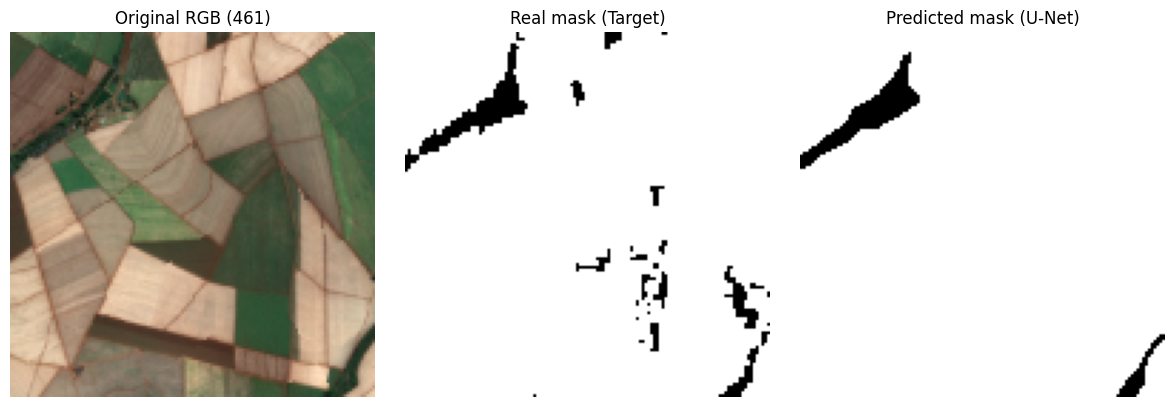

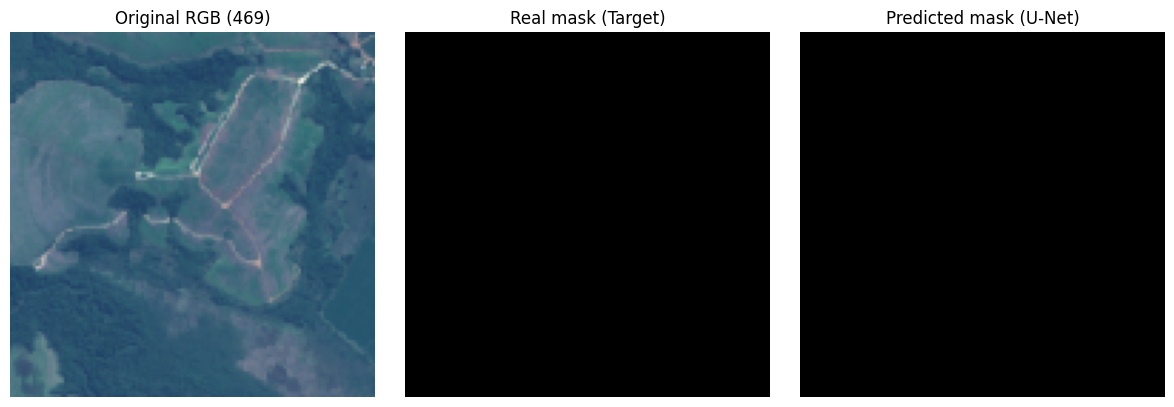

In [29]:
# Make all the predictions on the test set and visualize 4 random results

max_plots = 4  # Number of images to visualize

all_predictions = []  # List to accumulate all predictions

j = 0 # Counter for saved figure filenames

i_numbers = random.sample(range(len(X_test)), k=max_plots) # Randomly select indices for visualization

for i in range(len(X_test)):
    # 1. Extract single image and make prediction
    single_img = X_test[i][np.newaxis, ...]
    pred = model.predict(single_img, verbose=0)
    
    # Remove batch dimension
    pred_squeezed = pred[0]
    all_predictions.append(pred_squeezed)
    
    # 2. VISUALIZATION SETUP (Only for the first X images)
    if i in i_numbers:
        binary_pred = pred_squeezed > 0.5
        fig, ax = plt.subplots(1, 3, figsize=(12, 4))
        
        # Extract RGB channels [Red=2, Green=1, Blue=0]
        # Clip to [0, 1] bounds so matplotlib displays colors accurately
        rgb_img = np.clip(X_test[i][..., [2, 1, 0]], 0, 1)

        ax[0].imshow(rgb_img)
        ax[0].set_title(f"Original RGB ({i})")
        ax[0].axis('off')
        
        ax[1].imshow(y_test[i].squeeze(), cmap='gray')
        ax[1].set_title("Real mask (Target)")
        ax[1].axis('off')
        
        ax[2].imshow(binary_pred.squeeze(), cmap='gray')
        ax[2].set_title("Predicted mask (U-Net)")
        ax[2].axis('off')
        
        file_path = base_path / "figures" / f"unet_sugarcane_results_{j}.png"
        file_path.parent.mkdir(parents=True, exist_ok=True)
        j += 1
        
        plt.tight_layout()
        plt.savefig(file_path, dpi=300, bbox_inches='tight')
        plt.show()

In [27]:
# Metrics Calculation

# 1. Convert all collected predictions into a matching NumPy array
# Shape will become (N, H, W, C) matching y_train
y_pred_all = np.array(all_predictions)

# 2. Transform both entire sets into binary integers
y_pred_bin = (y_pred_all > 0.5).astype(int)
y_true_bin = y_test.astype(int)

# 3. Flatten the entire sets to 1D arrays
y_true_flat = y_true_bin.ravel()
y_pred_flat = y_pred_bin.ravel()

# 3.5. Calculate float probailities
y_true_float = y_test.astype(float).ravel()
y_pred_float = y_pred_all.astype(float).ravel()

# 4. Calculate global metrics
p = precision_score(y_true_flat, y_pred_flat, zero_division=0)
r = recall_score(y_true_flat, y_pred_flat, zero_division=0)
f1 = f1_score(y_true_flat, y_pred_flat, zero_division=0)
roc_auc = roc_auc_score(y_true_flat, y_pred_flat)

print(f"Metrics for the entire dataset:")
print(f"Precision: {p:.4f}")
print(f"Recall: {r:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_true_flat, y_pred_flat)
print("\nConfusion Matrix:")
print(cm)

# 6. Classification Report
print("\nClassification Report:")
print(classification_report(y_true_flat, y_pred_flat, zero_division=0))

Metrics for the entire dataset:
Precision: 0.9311
Recall: 0.9613
F1-Score: 0.9460
ROC AUC Score: 0.9606

Confusion Matrix:
[[5282219  220406]
 [ 119926 2979049]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97   5502625
           1       0.93      0.96      0.95   3098975

    accuracy                           0.96   8601600
   macro avg       0.95      0.96      0.96   8601600
weighted avg       0.96      0.96      0.96   8601600



/tmp/ipykernel_867294/1581254744.py:75: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(file_path, dpi=300, bbox_inches='tight')



Visualization saved as '/home/fdesmello/Git/spacesugar/figures/unet_sugarcane_results.png'


/home/fdesmello/miniconda3/envs/sugarcane/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


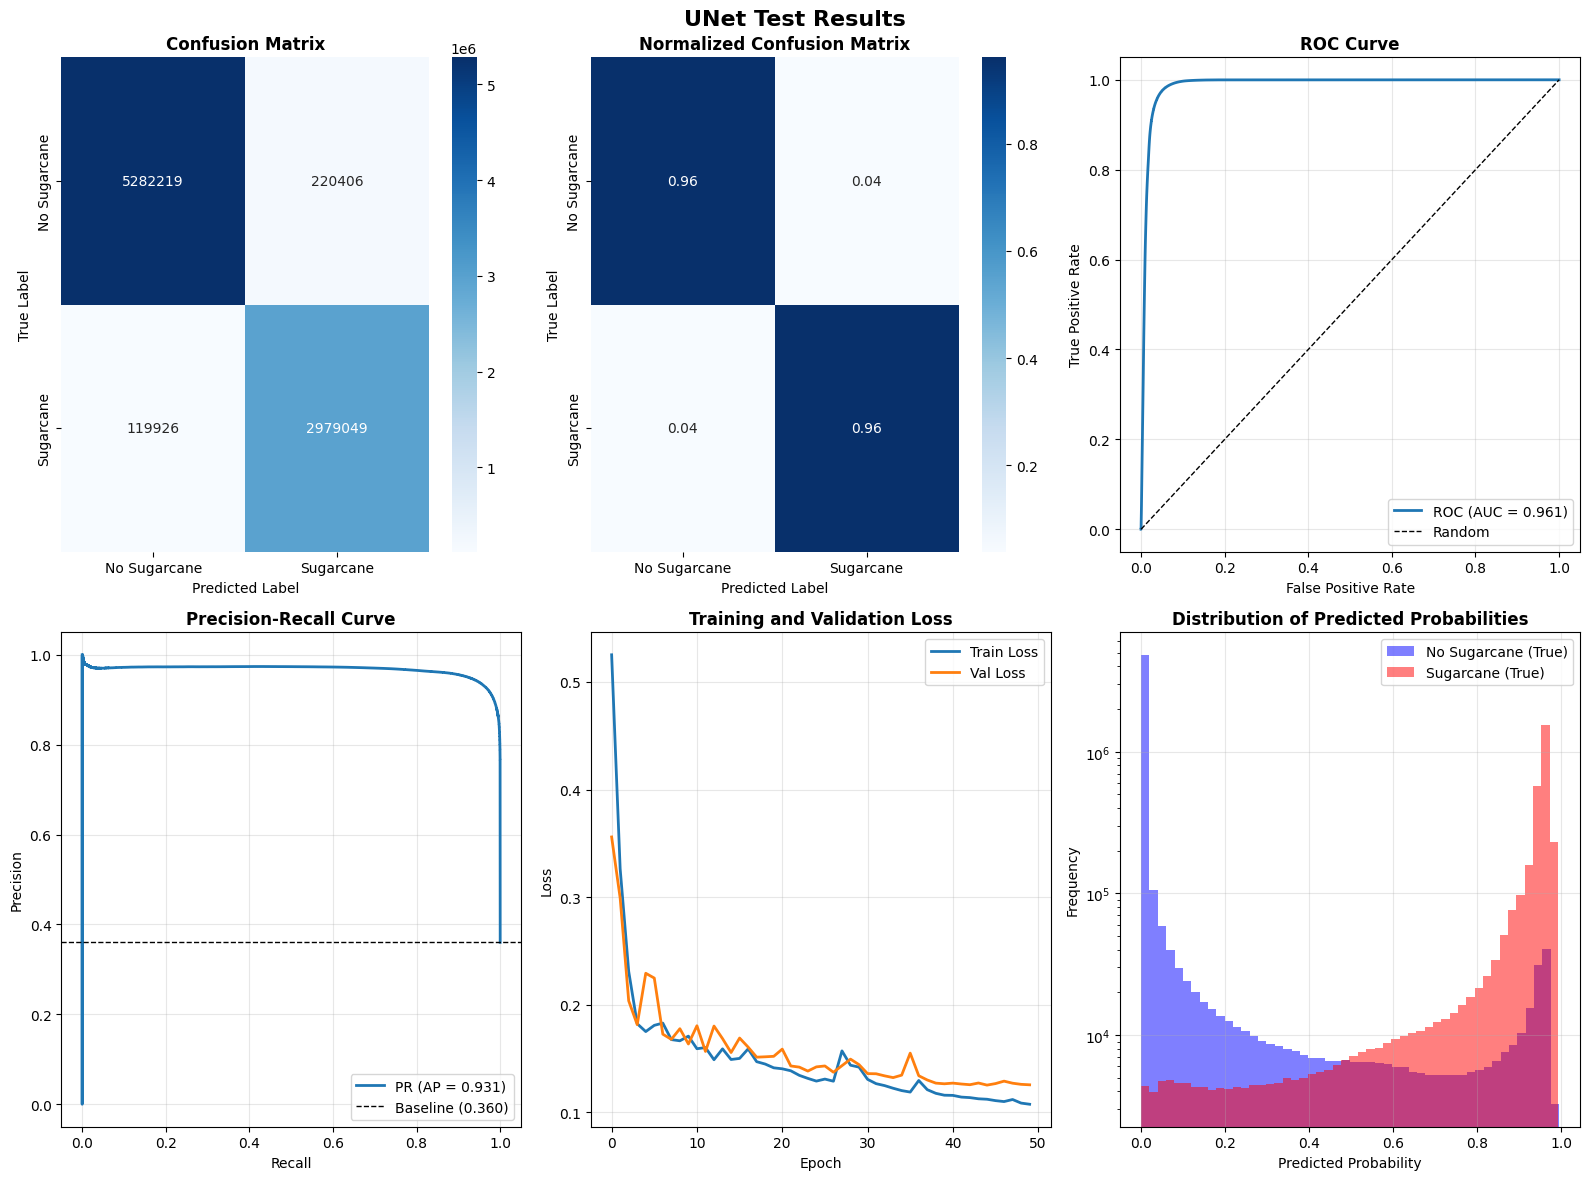

In [28]:
# Visualizations

fig = plt.figure(figsize=(16, 12))
plt.suptitle('UNet Test Results', fontsize=16, fontweight='bold')

class_names = ['No Sugarcane', 'Sugarcane']

# 1. Confusion Matrix
ax1 = plt.subplot(2, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, xticklabels=class_names, yticklabels=class_names)
ax1.set_title('Confusion Matrix', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')

# 2. Normalized Confusion Matrix
cm_norm = pd.DataFrame(cm).apply(lambda x: x/sum(x), axis = 1)
ax2 = plt.subplot(2, 3, 2)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap='Blues', ax=ax2, xticklabels=class_names, yticklabels=class_names)
ax2.set_title('Normalized Confusion Matrix', fontsize=12, fontweight='bold')
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')

# 3. ROC Curve
if len(np.unique(y_true_float)) > 1:
    ax3 = plt.subplot(2, 3, 3)
    fpr, tpr, _ = roc_curve(y_true_flat, y_pred_float)
    ax3.plot(fpr, tpr, linewidth=2, label=f'ROC (AUC = {roc_auc:.3f})')
    ax3.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
    ax3.set_xlabel('False Positive Rate')
    ax3.set_ylabel('True Positive Rate')
    ax3.set_title('ROC Curve', fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

# 4. Precision-Recall Curve
if len(np.unique(y_true_float)) > 1:
    ax4 = plt.subplot(2, 3, 4)
    precision, recall, _ = precision_recall_curve(y_true_flat, y_pred_float)
    ax4.plot(recall, precision, linewidth=2, label=f'PR (AP = {p:.3f})')
    ax4.axhline(y=y_true_flat.mean(), color='k', linestyle='--', linewidth=1, 
                label=f'Baseline ({y_true_flat.mean():.3f})')
    ax4.set_xlabel('Recall')
    ax4.set_ylabel('Precision')
    ax4.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

# 5. Training and Validation Loss
if history_dict:
    hist = history.history
    ax5 = plt.subplot(2, 3, 5)
    ax5.plot(hist['loss'], label='Train Loss', linewidth=2)
    if 'val_loss' in hist:
        ax5.plot(hist['val_loss'], label='Val Loss', linewidth=2)
    ax5.set_xlabel('Epoch')
    ax5.set_ylabel('Loss')
    ax5.set_title('Training and Validation Loss', fontsize=12, fontweight='bold')
    ax5.legend()
    ax5.grid(True, alpha=0.3)

# 6. Prediction Probability Distribution
ax6 = plt.subplot(2, 3, 6)
ax6.hist(y_pred_float[y_true_flat == 0], bins=50, alpha=0.5, label='No Sugarcane (True)', color='blue')
ax6.hist(y_pred_float[y_true_flat == 1], bins=50, alpha=0.5, label='Sugarcane (True)', color='red')
ax6.set_xlabel('Predicted Probability')
ax6.set_ylabel('Frequency')
ax6.set_yscale('log')
ax6.set_title('Distribution of Predicted Probabilities', fontsize=12, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()

file_path = base_path / "figures" / "unet_sugarcane_results.png"
plt.savefig(file_path, dpi=300, bbox_inches='tight')
print(f"\nVisualization saved as '{file_path}'")

plt.show()